# Fraud Detection in Electricity and Gas Consumption Challenge

This is a simple starter notebook based on the tutorial prepared by Joy Wawira. Check out the article [here](https://zindi.africa/learn/fraud-detection-in-electricity-and-gas-consumption-challenge-tutorial) for a more detailed description of the steps taken.

This notebook covers:
- Downloading the data straight from Zindi and onto colab
- Loading the data and carrying out simple EDA to understand the data and prepare for modelling 
- Preprocessing the data and feature engineering 
- Creating a simple LGBM model and predicting on the test set
- Prepare submission file and save as csv
- Some tips on how to improve model performance and your score

# Data Prep

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
# import lightgbm
from lightgbm import LGBMClassifier

import warnings
warnings.simplefilter('ignore')

## Read the Data

In [2]:
client_train = pd.read_csv('data/client_train.csv', low_memory=False)
invoice_train = pd.read_csv('data/invoice_train.csv', low_memory=False)

client_test = pd.read_csv(f'data/client_test.csv', low_memory=False)
invoice_test = pd.read_csv(f'data/invoice_test.csv', low_memory=False)
sample_submission = pd.read_csv(f'results/SampleSubmission.csv', low_memory=False)

## Data Understanding

In [3]:
#compare size of the various datasets
print(client_train.shape, invoice_train.shape, client_test.shape, invoice_train.shape)

(135493, 6) (4476749, 16) (58069, 5) (4476749, 16)


In [5]:
#print top rows of dataset
invoice_train[invoice_train['client_id'] == 'train_Client_99997']
print(invoice_train.counter_type.value_counts())
print(invoice_train.tarif_type.value_counts())


counter_type
ELEC    3079406
GAZ     1397343
Name: count, dtype: int64
tarif_type
11    2679872
40    1379755
10     276210
15      72422
45      17552
13      11656
14      11611
12      11345
29      10090
9        6039
21        104
8          43
30         35
24          9
18          4
42          1
27          1
Name: count, dtype: int64


In [6]:
#print top rows of dataset
client_train.head()

,disrict,client_id,client_catg,region,creation_date,target
0,60,train_Client_0,11,101,31/12/1994,0.0
1,69,train_Client_1,11,107,29/05/2002,0.0
2,62,train_Client_10,11,301,13/03/1986,0.0
3,69,train_Client_100,11,105,11/07/1996,0.0
4,62,train_Client_1000,11,303,14/10/2014,0.0


In [7]:
#Get a summary for all numerical columns
invoice_train.describe().T

,count,mean,std,min,25%,50%,75%,max
tarif_type,4476749.0,2.012804e+01,1.347256e+01,8.0,11.0,11.0,40.0,4.500000e+01
counter_number,4476749.0,1.230587e+11,1.657267e+12,0.0,121108.0,494561.0,1115161.0,2.798115e+13
counter_code,4476749.0,1.724884e+02,1.338871e+02,0.0,5.0,203.0,207.0,6.000000e+02
reading_remarque,4476749.0,7.321702e+00,1.571654e+00,5.0,6.0,8.0,9.0,4.130000e+02
counter_coefficient,4476749.0,1.003040e+00,3.083466e-01,0.0,1.0,1.0,1.0,5.000000e+01
consommation_level_1,4476749.0,4.109795e+02,7.573080e+02,0.0,79.0,274.0,600.0,9.999100e+05
consommation_level_2,4476749.0,1.093225e+02,1.220123e+03,0.0,0.0,0.0,0.0,9.990730e+05
consommation_level_3,4476749.0,2.030620e+01,1.574239e+02,0.0,0.0,0.0,0.0,6.449200e+04
consommation_level_4,4476749.0,5.292588e+01,8.754725e+02,0.0,0.0,0.0,0.0,5.479460e+05
old_index,4476749.0,1.776700e+04,4.036693e+04,0.0,1791.0,7690.0,21660.0,2.800280e+06


In [8]:
invoice_train.reading_remarque.value_counts()

reading_remarque
6      2230939
9      1416992
8       828123
7          661
203         15
413         12
207          6
5            1
Name: count, dtype: int64

In [ ]:
#Get a summary for all numerical columns
client_train.describe().T

,count,mean,std,min,25%,50%,75%,max
disrict,135493.0,63.511222,3.354400,60.0,62.0,62.0,69.0,69.0
client_catg,135493.0,11.512506,4.423761,11.0,11.0,11.0,11.0,51.0
region,135493.0,206.159809,104.207044,101.0,103.0,107.0,307.0,399.0
target,135493.0,0.055841,0.229614,0.0,0.0,0.0,0.0,1.0


In [ ]:
#Get concise information of each column in dataset
invoice_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4476749 entries, 0 to 4476748
Data columns (total 16 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   client_id             object
 1   invoice_date          object
 2   tarif_type            int64 
 3   counter_number        int64 
 4   counter_statue        object
 5   counter_code          int64 
 6   reading_remarque      int64 
 7   counter_coefficient   int64 
 8   consommation_level_1  int64 
 9   consommation_level_2  int64 
 10  consommation_level_3  int64 
 11  consommation_level_4  int64 
 12  old_index             int64 
 13  new_index             int64 
 14  months_number         int64 
 15  counter_type          object
dtypes: int64(12), object(4)
memory usage: 546.5+ MB


In [17]:
invoice_train.counter_statue.unique()
invoice_train[invoice_train['counter_statue'] == 'A']

invoice_train[invoice_train['client_id'] == 'train_Client_100037']
invoice_train.sort_values(['client_id', 'invoice_date'])[invoice_train['client_id'] == 'train_Client_100037']


,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
1517,train_Client_100037,2010-05-19,11,125055,0,203,6,1,2331,0,0,0,509,2840,8,ELEC
1518,train_Client_100037,2010-09-16,11,125055,0,203,8,1,1121,0,0,0,2840,3961,4,ELEC
1519,train_Client_100037,2011-09-19,11,125055,0,203,9,1,1060,0,0,0,5635,6695,6,ELEC
1520,train_Client_100037,2012-01-19,11,125055,0,203,6,1,832,0,0,0,6695,7527,4,ELEC
1509,train_Client_100037,2012-09-19,11,125055,0,203,8,1,2144,0,0,0,7527,9671,8,ELEC
1521,train_Client_100037,2013-01-29,11,125055,0,203,6,1,877,0,0,0,9671,10548,4,ELEC
1530,train_Client_100037,2013-05-22,11,125055,0,203,8,1,509,0,0,0,10548,11057,4,ELEC
1529,train_Client_100037,2013-09-19,11,125055,0,203,8,1,381,0,0,0,11057,11438,4,ELEC
1522,train_Client_100037,2014-01-27,11,125055,0,203,8,1,372,0,0,0,11438,11810,4,ELEC
1523,train_Client_100037,2014-05-22,11,125055,0,203,8,1,327,0,0,0,11810,12137,4,ELEC


In [ ]:
client_train[client_train['client_id'] == 'train_Client_100037']
client_train[client_train['target'] == 1]

,disrict,client_id,client_catg,region,creation_date,target
46,62,train_Client_100037,11,307,16/09/2009,1.0


In [28]:
client_train[client_train['client_id'] == 'train_Client_30467']

,disrict,client_id,client_catg,region,creation_date,target
58237,60,train_Client_30467,11,101,21/05/1979,0.0


In [ ]:
#Get concise information of each column in dataset
client_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135493 entries, 0 to 135492
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   disrict        135493 non-null  int64  
 1   client_id      135493 non-null  object 
 2   client_catg    135493 non-null  int64  
 3   region         135493 non-null  int64  
 4   creation_date  135493 non-null  object 
 5   target         135493 non-null  float64
dtypes: float64(1), int64(3), object(2)
memory usage: 6.2+ MB


In [29]:
client_train.target.unique()

array([0., 1.])

In [30]:
invoice_train.counter_statue.value_counts()

counter_statue
0         4379008
1           74036
5           20639
4            2729
3             258
2              32
46             14
A              13
618            12
769             6
269375          1
420             1
Name: count, dtype: int64

In [31]:
invoice_train.reading_remarque.value_counts()

reading_remarque
6      2230939
9      1416992
8       828123
7          661
203         15
413         12
207          6
5            1
Name: count, dtype: int64

In [32]:
invoice_train.counter_code.value_counts()

counter_code
203    1516836
5      1352035
207     555628
413     378917
202     343251
420      98273
410      69080
433      34447
10       27744
442      17050
25       14934
407      13768
204      12427
453       8290
201       7672
467       7302
506       3389
483       2830
214       2643
40        2482
532       1982
565       1082
403       1070
450       1059
600        807
210        789
102        313
227        178
65          74
101         74
16          73
310         51
307         50
305         44
222         42
0           33
317         16
303          5
333          4
367          3
325          1
1            1
Name: count, dtype: int64

1.2112328767123288

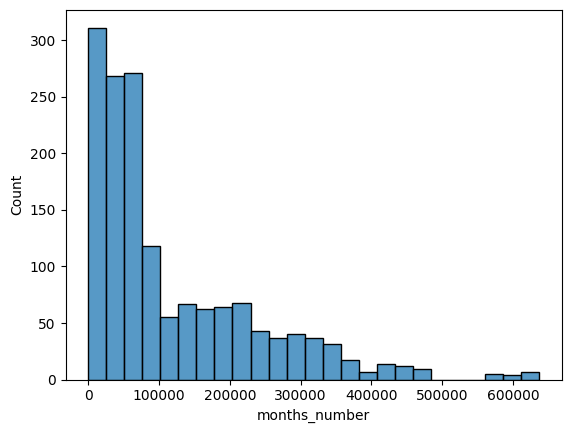

In [ ]:
import seaborn as sns
df=invoice_train[invoice_train['months_number'] >= 50]
sns.histplot(data=df, x='months_number')
invoice_train['months_number'].max()


#### months_number
Why are some values very large? Wrong unit entered into the data? 

#### counter_statue
Should only take 5 different categories, but has 12 different. Most of the clients find themselves in the range 0-5 (which is already 6 values, where only 32 entries were '2')
One has a string (all the same client, having 2 ELEC and one GAZ) 'A' as a value. Consumption of 50 once in 15 entries. No fraudster. 
Other values seem random: 420, 69394, ...

#### Districts and Regions
Tunisia has 5 districts and 24 governorates. We should check if the data regions can be located in separate districts. If not, we can use both columns as they are.

In [ ]:
#Getting unique values on the invoice train data
for col in invoice_train.columns:
    print(f"{col} - {invoice_train[col].nunique()}")

client_id - 135493
invoice_date - 8275
tarif_type - 17
counter_number - 201893
counter_statue - 12
counter_code - 42
reading_remarque - 8
counter_coefficient - 16
consommation_level_1 - 8295
consommation_level_2 - 12576
consommation_level_3 - 2253
consommation_level_4 - 12075
old_index - 155648
new_index - 157980
months_number - 1370
counter_type - 2


In [ ]:
#Getting unique values on the invoice train data
for col in client_train.columns:
    print(f"{col} - {client_train[col].nunique()}")

disrict - 4
client_id - 135493
client_catg - 3
region - 25
creation_date - 8088
target - 2


In [47]:
client_train.client_catg.value_counts()

client_catg
11    131494
12      2321
51      1678
Name: count, dtype: int64

In [49]:
invoice_train.tail(15)

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
4476734,train_Client_99997,2013-12-06,40,0,0,5,9,1,52,0,0,0,311,363,4,GAZ
4476735,train_Client_99997,2012-12-10,40,0,0,5,9,1,38,0,0,0,190,228,4,GAZ
4476736,train_Client_99997,2019-07-02,11,262195,0,207,9,1,1075,0,0,0,7430,8505,8,ELEC
4476737,train_Client_99997,2018-06-02,11,262195,0,207,9,1,386,0,0,0,6528,6914,4,ELEC
4476738,train_Client_99997,2013-02-19,40,0,0,5,9,1,83,0,0,0,228,311,4,GAZ
4476739,train_Client_99997,2013-12-06,11,262195,0,207,9,1,282,0,0,0,1608,1890,4,ELEC
4476740,train_Client_99997,2014-02-17,11,262195,0,207,9,1,341,0,0,0,2221,2562,4,ELEC
4476741,train_Client_99997,2014-02-17,40,0,0,5,9,1,118,0,0,0,406,524,4,GAZ
4476742,train_Client_99997,2014-06-13,11,262195,0,207,9,1,312,0,0,0,2562,2874,4,ELEC
4476743,train_Client_99997,2019-11-06,11,262195,0,207,9,1,578,0,0,0,8505,9083,4,ELEC


In [ ]:
#check for missing values
invoice_train.isnull().sum()

client_id               0
invoice_date            0
tarif_type              0
counter_number          0
counter_statue          0
counter_code            0
reading_remarque        0
counter_coefficient     0
consommation_level_1    0
consommation_level_2    0
consommation_level_3    0
consommation_level_4    0
old_index               0
new_index               0
months_number           0
counter_type            0
dtype: int64

In [ ]:
#check for missing values
client_train.isnull().sum()

disrict          0
client_id        0
client_catg      0
region           0
creation_date    0
target           0
dtype: int64

No missing values in train set

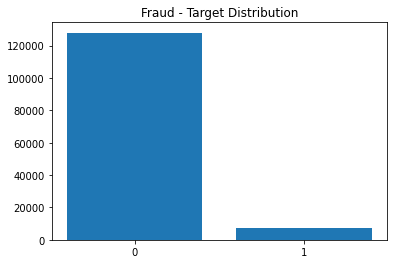

In [ ]:
#Visualize fraudulent activities
fraudactivities = client_train.groupby(['target'])['client_id'].count()
plt.bar(x=fraudactivities.index, height=fraudactivities.values, tick_label = [0,1])
plt.title('Fraud - Target Distribution')
plt.show()

Target is highly imbalanced with fewer cases of fraudulent activities

disrict
60    31922
62    40353
63    28987
69    34231
Name: client_id, dtype: int64

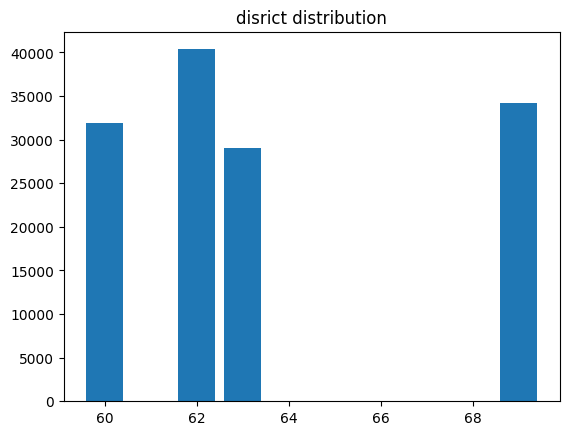

region
101    33770
103     8964
104    12865
105     1645
106      706
107     9998
199        2
206       53
301     9544
302     4311
303     5982
304     3828
305     2716
306     6044
307     3376
308      841
309     3669
310     4851
311    12406
312     4379
313     2076
371     2065
372      644
379      583
399      175
Name: client_id, dtype: int64

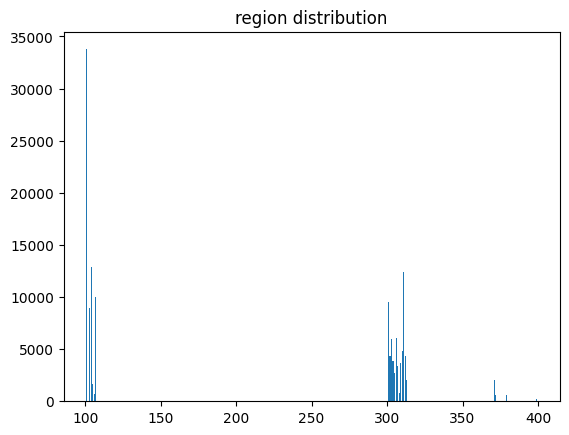

In [50]:
#Visualize client distribution across districts and regions
for col in ['disrict','region']:
    region = client_train.groupby([col])['client_id'].count()
    display(region)
    plt.bar(x=region.index, height=region.values)
    plt.title(col+' distribution')
    plt.show()

## Feature Engineering

In [51]:
#convert the column invoice_date to date time format on both the invoice train and invoice test
for df in [invoice_train,invoice_test]:
    df['invoice_date'] = pd.to_datetime(df['invoice_date'])

In [52]:
#encode labels in categorical column
d={"ELEC":0,"GAZ":1}
invoice_train['counter_type']=invoice_train['counter_type'].map(d)
invoice_test['counter_type']=invoice_test['counter_type'].map(d)

In [53]:
#convert categorical columns to int for model
client_train['client_catg'] = client_train['client_catg'].astype(int)
client_train['disrict'] = client_train['disrict'].astype(int)

client_test['client_catg'] = client_test['client_catg'].astype(int)
client_test['disrict'] = client_test['disrict'].astype(int)

In [54]:
def aggregate_by_client_id(invoice_data):
    aggs = {}
    aggs['consommation_level_1'] = ['mean']
    aggs['consommation_level_2'] = ['mean']
    aggs['consommation_level_3'] = ['mean']
    aggs['consommation_level_4'] = ['mean']

    agg_trans = invoice_data.groupby(['client_id']).agg(aggs)
    agg_trans.columns = ['_'.join(col).strip() for col in agg_trans.columns.values]
    agg_trans.reset_index(inplace=True)

    df = (invoice_data.groupby('client_id')
            .size()
            .reset_index(name='{}transactions_count'.format('1')))
    return pd.merge(df, agg_trans, on='client_id', how='left')

In [65]:
invoice_train.groupby('client_id').size().reset_index(name='{}transactions_count'.format('1'))

,client_id,1transactions_count
0,train_Client_0,35
1,train_Client_1,37
2,train_Client_10,18
3,train_Client_100,20
4,train_Client_1000,14
...,...,...
135488,train_Client_99995,71
135489,train_Client_99996,41
135490,train_Client_99997,36
135491,train_Client_99998,2


In [55]:
#group invoice data by client_id
agg_train = aggregate_by_client_id(invoice_train)

In [57]:
agg_train.head()

,client_id,1transactions_count,consommation_level_1_mean,consommation_level_2_mean,consommation_level_3_mean,consommation_level_4_mean
0,train_Client_0,35,352.400000,10.571429,0.000000,0.000000
1,train_Client_1,37,557.540541,0.000000,0.000000,0.000000
2,train_Client_10,18,798.611111,37.888889,0.000000,0.000000
3,train_Client_100,20,1.200000,0.000000,0.000000,0.000000
4,train_Client_1000,14,663.714286,104.857143,117.357143,36.714286


In [ ]:
print(agg_train.shape)
agg_train.head()

(135493, 6)


,client_id,1transactions_count,consommation_level_1_mean,consommation_level_2_mean,consommation_level_3_mean,consommation_level_4_mean
0,train_Client_0,35,352.400000,10.571429,0.000000,0.000000
1,train_Client_1,37,557.540541,0.000000,0.000000,0.000000
2,train_Client_10,18,798.611111,37.888889,0.000000,0.000000
3,train_Client_100,20,1.200000,0.000000,0.000000,0.000000
4,train_Client_1000,14,663.714286,104.857143,117.357143,36.714286


In [67]:
#merge aggregate data with client dataset
train = pd.merge(client_train,agg_train, on='client_id', how='left')
display(train)

,disrict,client_id,client_catg,region,creation_date,target,1transactions_count,consommation_level_1_mean,consommation_level_2_mean,consommation_level_3_mean,consommation_level_4_mean
0,60,train_Client_0,11,101,31/12/1994,0.0,35,352.400000,10.571429,0.000000,0.000000
1,69,train_Client_1,11,107,29/05/2002,0.0,37,557.540541,0.000000,0.000000,0.000000
2,62,train_Client_10,11,301,13/03/1986,0.0,18,798.611111,37.888889,0.000000,0.000000
3,69,train_Client_100,11,105,11/07/1996,0.0,20,1.200000,0.000000,0.000000,0.000000
4,62,train_Client_1000,11,303,14/10/2014,0.0,14,663.714286,104.857143,117.357143,36.714286
...,...,...,...,...,...,...,...,...,...,...,...
135488,62,train_Client_99995,11,304,26/07/2004,0.0,71,1.957746,0.000000,0.000000,0.000000
135489,63,train_Client_99996,11,311,25/10/2012,0.0,41,185.853659,0.756098,0.000000,0.000000
135490,63,train_Client_99997,11,311,22/11/2011,0.0,36,273.083333,0.000000,0.000000,0.000000
135491,60,train_Client_99998,11,101,22/12/1993,0.0,2,300.000000,70.500000,0.000000,0.000000


In [68]:
#aggregate test set
agg_test = aggregate_by_client_id(invoice_test)
test = pd.merge(client_test,agg_test, on='client_id', how='left')

In [69]:
train.shape, test.shape

((135493, 11), (58069, 10))

In [70]:
#drop redundant columns
sub_client_id = test['client_id']
drop_columns = ['client_id', 'creation_date']

for col in drop_columns:
    if col in train.columns:
        train.drop([col], axis=1, inplace=True)
    if col in test.columns:
        test.drop([col], axis=1, inplace=True)

# Modelling

## Train LGBM *Classifier*

In [71]:
x_train = train.drop(columns=['target'])
y_train = train['target']

In [76]:
model = LGBMClassifier(boosting_type='gbdt', num_iterations=500)
model.fit(x_train, y_train)

[LightGBM] [Info] Number of positive: 7566, number of negative: 127927
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006760 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1296
[LightGBM] [Info] Number of data points in the train set: 135493, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.055841 -> initscore=-2.827795
[LightGBM] [Info] Start training from score -2.827795


LGBMClassifier(num_iterations=500)

## Make Predictions on test set

In [78]:
test.columns

Index(['disrict', 'client_catg', 'region', '1transactions_count',
       'consommation_level_1_mean', 'consommation_level_2_mean',
       'consommation_level_3_mean', 'consommation_level_4_mean'],
      dtype='object')

In [79]:
preds = model.predict(test)
preds = pd.DataFrame(preds, columns=['target'])
preds.head()

,target
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [80]:
submission = pd.DataFrame(
    {
        'client_id': sub_client_id,
        'target': preds['target']
    }
)

submission.head()

,client_id,target
0,test_Client_0,0.0
1,test_Client_1,0.0
2,test_Client_10,0.0
3,test_Client_100,0.0
4,test_Client_1000,0.0


In [81]:
submission.to_csv(f'results/submission_baseline.csv', index=False)

## Tips 
- Thorough EDA and incorporating domain knowledge
- Re-grouping categorical features
- More feature engineering(try utilizing some date-time features)
- Target balancing - oversampling, undersampling, SMOTE, scale_pos_weight
- Model ensembling
- Train-test split or cross-validation


# ******************* GOOD LUCK!!! ***************************